In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv("multiple_regression_eda_feature_engineering_dataset.csv")
df.head()

,employee_id,age,experience_years,education,education_years,city,department,job_level,remote_work,company_size,training_hours,projects_completed,performance_score,weekly_work_hours,commute_minutes,job_satisfaction,bonus_percentage,annual_salary
0,EMP100001,24,0.0,Bachelor,16,Delhi,HR,Senior,Yes,Medium,49.2,11,79.9,32.5,47.1,5.5,9.64,1180200
1,EMP100002,51,30.8,High School,12,Delhi,Operations,Senior,No,Small,5.0,41,55.4,41.1,27.9,7.7,9.60,1377500
2,EMP100003,47,23.0,High School,12,Mumbai,Marketing,Junior,No,Medium,7.9,30,65.2,65.8,6.8,6.0,1.45,1128200
3,EMP100004,38,7.8,High School,12,Hyderabad,Finance,Senior,No,Small,NaN,5,63.1,37.0,15.0,7.4,9.11,1077100
4,EMP100005,38,16.3,Master,18,Chennai,HR,Senior,Yes,Medium,72.9,16,98.7,45.0,27.0,8.8,10.80,1606500


In [4]:
df.shape

(10025, 18)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10025 entries, 0 to 10024
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         10025 non-null  str    
 1   age                 10025 non-null  int64  
 2   experience_years    9904 non-null   float64
 3   education           9945 non-null   str    
 4   education_years     10025 non-null  int64  
 5   city                9925 non-null   str    
 6   department          10025 non-null  str    
 7   job_level           10025 non-null  str    
 8   remote_work         10025 non-null  str    
 9   company_size        10025 non-null  str    
 10  training_hours      9845 non-null   float64
 11  projects_completed  10025 non-null  int64  
 12  performance_score   9905 non-null   float64
 13  weekly_work_hours   10025 non-null  float64
 14  commute_minutes     9875 non-null   float64
 15  job_satisfaction    9824 non-null   float64
 16  bonus_percentag

In [6]:
df.describe()

,age,experience_years,education_years,training_hours,projects_completed,performance_score,weekly_work_hours,commute_minutes,job_satisfaction,bonus_percentage,annual_salary
count,10025.000000,9904.000000,10025.000000,9845.000000,10025.000000,9905.000000,10025.000000,9875.000000,9824.000000,9925.000000,1.002500e+04
mean,40.356908,14.177423,16.124888,45.616293,19.655062,81.555023,43.938344,32.808759,7.124145,7.345553,1.338749e+06
std,11.488200,11.111090,2.294978,29.027512,12.730717,13.848858,7.017634,21.933661,1.200867,2.618447,2.427380e+05
min,21.000000,0.000000,12.000000,5.000000,0.000000,36.000000,25.000000,5.000000,1.000000,0.000000,5.859000e+05
25%,30.000000,3.575000,16.000000,24.500000,9.000000,71.000000,39.200000,16.400000,6.300000,5.590000,1.162700e+06
50%,40.000000,13.500000,16.000000,39.700000,19.000000,81.800000,43.900000,28.000000,7.100000,7.310000,1.336800e+06
75%,50.000000,23.300000,18.000000,60.600000,30.000000,94.000000,48.700000,43.900000,7.900000,9.100000,1.513100e+06
max,60.000000,35.000000,21.000000,180.000000,54.000000,100.000000,70.000000,120.000000,10.000000,17.270000,2.132400e+06


In [7]:
df.duplicated().sum()

np.int64(25)

In [8]:
df["employee_id"].nunique()

10000

In [9]:
df.isnull().sum()

employee_id             0
age                     0
experience_years      121
education              80
education_years         0
city                  100
department              0
job_level               0
remote_work             0
company_size            0
training_hours        180
projects_completed      0
performance_score     120
weekly_work_hours       0
commute_minutes       150
job_satisfaction      201
bonus_percentage      100
annual_salary           0
dtype: int64

In [10]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

job_satisfaction      2.004988
training_hours        1.795511
commute_minutes       1.496259
experience_years      1.206983
performance_score     1.197007
city                  0.997506
bonus_percentage      0.997506
education             0.798005
age                   0.000000
employee_id           0.000000
company_size          0.000000
remote_work           0.000000
job_level             0.000000
department            0.000000
education_years       0.000000
projects_completed    0.000000
weekly_work_hours     0.000000
annual_salary         0.000000
dtype: float64

In [11]:
df.nunique().sort_values()

remote_work               2
education                 4
job_level                 4
education_years           4
company_size              4
department                6
city                      8
age                      40
projects_completed       55
job_satisfaction         74
experience_years        351
weekly_work_hours       401
performance_score       569
commute_minutes         957
training_hours         1278
bonus_percentage       1289
annual_salary          6149
employee_id           10000
dtype: int64

In [12]:
df[df.duplicated()]

,employee_id,age,experience_years,education,education_years,city,department,job_level,remote_work,company_size,training_hours,projects_completed,performance_score,weekly_work_hours,commute_minutes,job_satisfaction,bonus_percentage,annual_salary
10000,EMP106253,32,4.6,Bachelor,16,Delhi,Operations,Mid,Yes,Medium,33.1,3,80.0,35.0,34.5,7.7,3.92,1091300
10001,EMP104685,41,10.3,Master,18,Chennai,Sales,Mid,No,Small,29.2,16,72.3,37.6,46.0,7.7,2.77,1145400
10002,EMP101732,57,33.2,Master,18,Kolkata,IT,Mid,Yes,Large,59.3,44,89.4,41.9,48.5,NaN,10.59,1552500
10003,EMP104743,38,NaN,High School,12,Delhi,IT,Senior,No,Large,61.9,21,88.3,34.2,37.0,7.1,10.65,1428800
10004,EMP104522,48,15.7,High School,12,Delhi,Sales,Junior,Yes,Small,120.0,26,100.0,35.0,8.6,6.1,8.54,1345100
10005,EMP106341,32,2.9,Master,18,Bangalore,IT,Senior,No,Medium,92.5,5,100.0,52.2,17.7,6.2,7.57,1476700
10006,EMP100577,58,24.3,Bachelor,16,Chennai,Marketing,Mid,Yes,Enterprise,58.2,27,87.9,30.9,19.5,8.8,8.31,1686400
10007,EMP105203,54,28.9,High School,12,Kolkata,Finance,Mid,No,Large,24.0,35,72.6,45.1,22.1,7.0,10.01,1320300
10008,EMP106364,31,0.0,High School,12,Mumbai,Marketing,Mid,No,Medium,53.4,5,82.2,52.4,75.7,6.6,7.69,1023900
10009,EMP100440,36,14.6,High School,12,Ahmedabad,HR,Manager,Yes,Small,26.6,18,78.9,53.4,32.8,8.8,10.07,1463900


In [13]:
df.dtypes

employee_id               str
age                     int64
experience_years      float64
education                 str
education_years         int64
city                      str
department                str
job_level                 str
remote_work               str
company_size              str
training_hours        float64
projects_completed      int64
performance_score     float64
weekly_work_hours     float64
commute_minutes       float64
job_satisfaction      float64
bonus_percentage      float64
annual_salary           int64
dtype: object

In [14]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


employee_id:
employee_id
EMP100440    2
EMP100577    2
EMP100583    2
EMP101732    2
EMP102250    2
            ..
EMP109996    1
EMP109997    1
EMP109998    1
EMP109999    1
EMP110000    1
Name: count, Length: 10000, dtype: int64

education:
education
Bachelor       4718
Master         2955
High School    1779
PhD             493
Name: count, dtype: int64

city:
city
Delhi        1282
Kolkata      1261
Hyderabad    1255
Bangalore    1244
Chennai      1242
Pune         1237
Mumbai       1202
Ahmedabad    1202
Name: count, dtype: int64

department:
department
Sales         1711
HR            1710
Marketing     1670
IT            1664
Operations    1658
Finance       1612
Name: count, dtype: int64

job_level:
job_level
Mid        3865
Senior     2673
Junior     2478
Manager    1009
Name: count, dtype: int64

remote_work:
remote_work
No     5494
Yes    4531
Name: count, dtype: int64

company_size:
company_size
Large         3441
Medium        3300
Small         1739
Enterprise    1545
Na

C:\Users\karan\AppData\Local\Temp\ipykernel_11300\1592738655.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [15]:
df = df.drop_duplicates().reset_index(drop=True)

In [16]:
df = df.drop(columns=['employee_id'])

In [17]:
df.shape

(10000, 17)

In [18]:
df['age'].describe()

count    10000.000000
mean        40.352000
std         11.490809
min         21.000000
25%         30.000000
50%         40.000000
75%         50.000000
max         60.000000
Name: age, dtype: float64

In [20]:
df['age'].isnull().sum()

np.int64(0)

In [22]:
df['age'].skew()

np.float64(0.024757150932175082)

<Axes: ylabel='Frequency'>

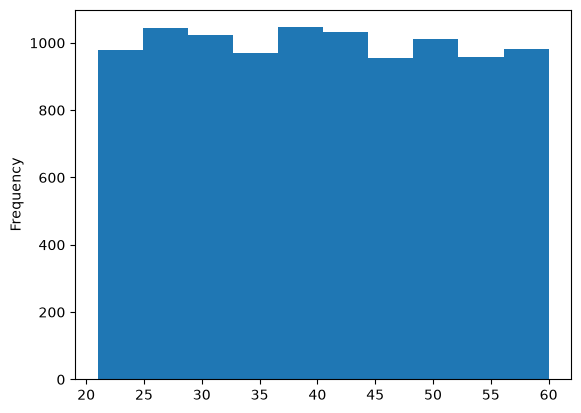

In [23]:
df['age'].plot(kind='hist')

<Axes: ylabel='Density'>

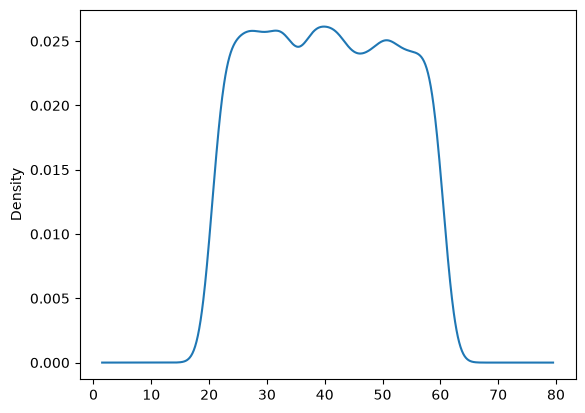

In [24]:
df['age'].plot(kind='kde')

<Axes: >

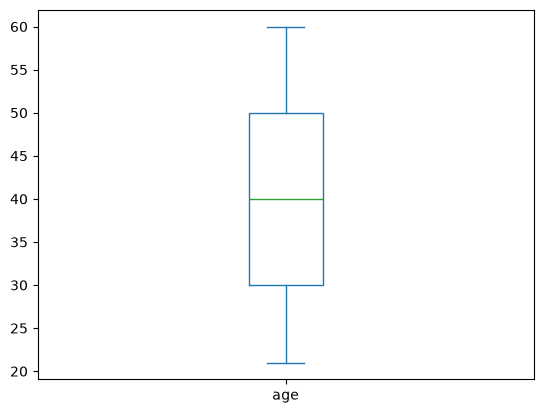

In [25]:
df['age'].plot(kind='box')

In [26]:
df['age'].corr(df['annual_salary'])

np.float64(0.6672068075176205)

In [28]:
df['experience_years'].isnull().sum()

np.int64(120)

In [29]:
df['experience_years'].describe()

count    9880.000000
mean       14.176619
std        11.111944
min         0.000000
25%         3.500000
50%        13.500000
75%        23.300000
max        35.000000
Name: experience_years, dtype: float64

In [30]:
df['experience_years'].skew()

np.float64(0.2549478897543204)

In [31]:
df['experience_years'].corr(df['annual_salary'])

np.float64(0.6966682288172168)

In [32]:
df['experience_years'].corr(df['age'])

np.float64(0.9168373857283343)

<Axes: ylabel='Density'>

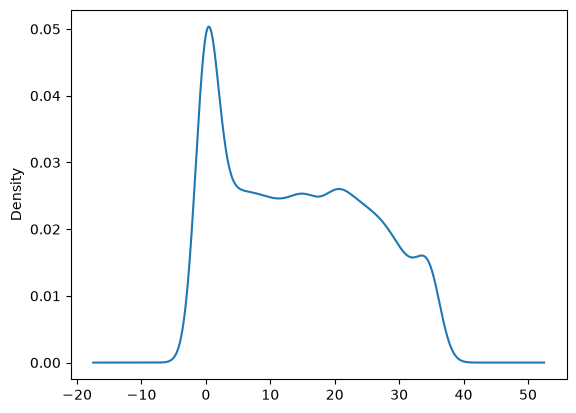

In [33]:
df['experience_years'].plot(kind='kde')

<Axes: ylabel='Frequency'>

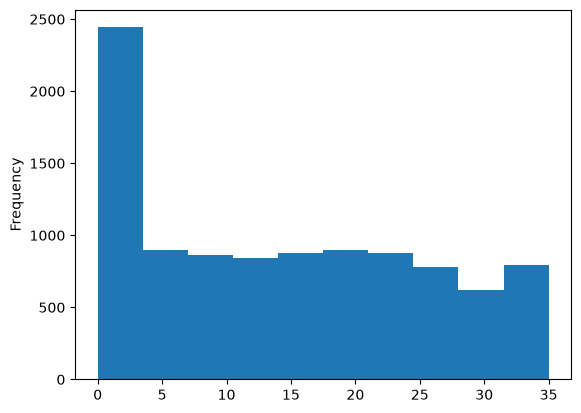

In [35]:
df['experience_years'].plot(kind='hist')

<Axes: >

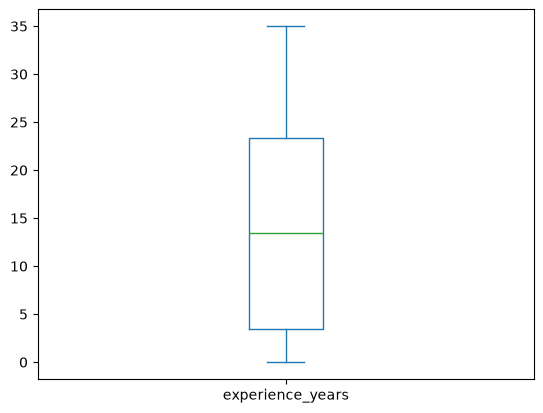

In [36]:
df['experience_years'].plot(kind='box')

In [37]:
# filling missing values
# Bachpan ke 5 saal + padhai ke saal minus karke bacha hua experience hota hai
logical_exp = df['age'] - df['education_years'] - 5

# Agar calculation negative aaye toh 0 set karenge (freshers)
logical_exp = logical_exp.clip(lower=0)

df['experience_years'] = df['experience_years'].fillna(logical_exp)

In [38]:
df['experience_years'].isnull().sum()

np.int64(0)

In [40]:
df['education'].dtype

<StringDtype(storage='python', na_value=nan)>

In [39]:
df['education'].isnull().sum()

np.int64(80)

In [41]:
df['education'].value_counts(dropna=False)

education
Bachelor       4710
Master         2948
High School    1769
PhD             493
NaN              80
Name: count, dtype: int64

In [44]:
pd.crosstab(df['education'].fillna('Missing'),df['education_years'])

education_years,12,16,18,21
education,,,,
Bachelor,0,4710,0,0
High School,1769,0,0,0
Master,0,0,2948,0
Missing,13,49,15,3
PhD,0,0,0,493


In [46]:
edu_map = {
  12: 'High School',
  16: 'Bachelor',
  18: 'Master',
  21: 'PhD'
}
df['education'] = df['education'].fillna(df['education_years'].map(edu_map))

In [47]:
df['education'].isnull().sum()

np.int64(0)

In [48]:
df['education_years'].dtype
df['education_years'].isnull().sum()
df['education_years'].value_counts().sort_index()

education_years
12    1782
16    4759
18    2963
21     496
Name: count, dtype: int64

In [49]:
df['education_years'].corr(df['annual_salary'])

np.float64(0.24651542314552352)

<Axes: >

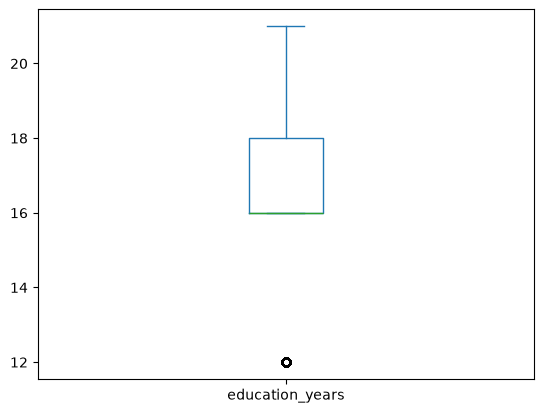

In [50]:
df['education_years'].plot(kind='box')

In [ ]:
df['city'].dtype

<StringDtype(storage='python', na_value=nan)>

In [53]:
df['city'].isnull().sum()

np.int64(100)

In [54]:
df['city'].isnull().sum() / (len(df)) * 100

np.float64(1.0)

In [55]:
df['city'].value_counts(dropna=False)

city
Delhi        1279
Kolkata      1258
Hyderabad    1254
Bangalore    1241
Chennai      1238
Pune         1235
Mumbai       1198
Ahmedabad    1197
NaN           100
Name: count, dtype: int64

In [ ]:
city_stats = df.groupby('city')['annual_salary'].agg(['count', 'mean', 'median', 'std'])
print(city_stats)

           count          mean     median            std
city                                                    
Ahmedabad   1197  1.325686e+06  1320300.0  246341.028610
Bangalore   1241  1.371876e+06  1359500.0  246082.303747
Chennai     1238  1.324690e+06  1321150.0  237403.230277
Delhi       1279  1.335614e+06  1337500.0  239833.334729
Hyderabad   1254  1.334214e+06  1337600.0  242419.905213
Kolkata     1258  1.315418e+06  1321500.0  242969.395784
Mumbai      1198  1.349935e+06  1337200.0  239492.259219
Pune        1235  1.354494e+06  1355200.0  244587.544557


In [62]:
df['city'] = df['city'].fillna(df['city'].mode()[0])

In [63]:
df['city'].isnull().sum()

np.int64(0)

In [65]:
df['department'].dtype

<StringDtype(storage='python', na_value=nan)>

In [66]:
df['department'].isnull().sum()

np.int64(0)

In [67]:
df['department'].value_counts()

department
Sales         1706
HR            1704
Marketing     1667
IT            1658
Operations    1654
Finance       1611
Name: count, dtype: int64

In [ ]:
dept_summary = df.groupby('department')['annual_salary'].agg(['count', 'mean', 'median', 'std'])
print(dept_summary)

            count          mean     median            std
department                                               
Finance      1611  1.342357e+06  1339100.0  244180.238148
HR           1704  1.332206e+06  1327700.0  241885.475365
IT           1658  1.348720e+06  1353550.0  242980.128658
Marketing    1667  1.332436e+06  1331300.0  249343.909986
Operations   1654  1.341043e+06  1341500.0  242317.404827
Sales        1706  1.336752e+06  1332650.0  236192.025239


In [70]:
df['job_level'].dtype

<StringDtype(storage='python', na_value=nan)>

In [71]:
df['job_level'].isnull().sum()

np.int64(0)

In [72]:
df['job_level'].value_counts()

job_level
Mid        3854
Senior     2668
Junior     2471
Manager    1007
Name: count, dtype: int64

In [73]:
level_order = ['Junior', 'Mid', 'Senior', 'Manager']
job_stats = df.groupby('job_level')['annual_salary'].agg(['count', 'mean', 'median', 'std']).reindex(level_order)
print(job_stats)

           count          mean     median            std
job_level                                               
Junior      2471  1.239970e+06  1242100.0  216784.284392
Mid         3854  1.306888e+06  1312050.0  226601.250843
Senior      2668  1.406016e+06  1413100.0  230216.030356
Manager     1007  1.525902e+06  1524800.0  242011.174114


In [75]:
print("Data Type:", df['remote_work'].dtype)
print("Missing Count:", df['remote_work'].isnull().sum())
print("\nCounts:")
print(df['remote_work'].value_counts())

Data Type: str
Missing Count: 0

Counts:
remote_work
No     5477
Yes    4523
Name: count, dtype: int64


In [76]:
remote_stats = df.groupby('remote_work')['annual_salary'].agg(['count', 'mean', 'median', 'std'])
print(remote_stats)

             count          mean     median            std
remote_work                                               
No            5477  1.328827e+06  1327000.0  241349.944042
Yes           4523  1.350997e+06  1349000.0  244065.325945


In [77]:
print("Data Type:", df['company_size'].dtype)
print("Missing Count:", df['company_size'].isnull().sum())
print("\nCompany Size Distribution:")
print(df['company_size'].value_counts())

Data Type: str
Missing Count: 0

Company Size Distribution:
company_size
Large         3433
Medium        3293
Small         1732
Enterprise    1542
Name: count, dtype: int64


In [78]:
size_order = ['Small', 'Medium', 'Large', 'Enterprise']
size_stats = df.groupby('company_size')['annual_salary'].agg(['count', 'mean', 'median', 'std']).reindex(size_order)
print(size_stats)

              count          mean     median            std
company_size                                               
Small          1732  1.327442e+06  1320300.0  238018.898618
Medium         3293  1.327960e+06  1326700.0  245994.369747
Large          3433  1.343421e+06  1340700.0  241574.254569
Enterprise     1542  1.364775e+06  1365600.0  242036.625811


In [79]:
print("Data Type:", df['training_hours'].dtype)
print("Missing Count:", df['training_hours'].isnull().sum())
print("Missing Percentage: {:.2f}%".format((df['training_hours'].isnull().sum() / len(df)) * 100))
print("\nSummary Statistics:")
print(df['training_hours'].describe())
print("\nSkewness:", df['training_hours'].skew())

Data Type: float64
Missing Count: 180
Missing Percentage: 1.80%

Summary Statistics:
count    9820.000000
mean       45.620377
std        29.040425
min         5.000000
25%        24.500000
50%        39.700000
75%        60.625000
max       180.000000
Name: training_hours, dtype: float64

Skewness: 1.187673330721969


In [80]:
df['training_hours'].corr(df['annual_salary'])

np.float64(0.43265406146371377)

In [81]:
df['training_hours'].corr(df['performance_score'])

np.float64(0.7703922198548363)

<Axes: >

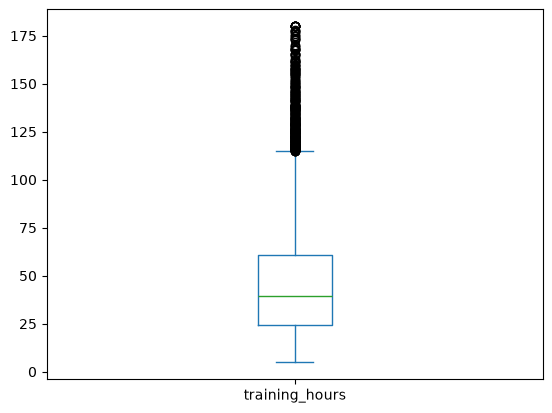

In [ ]:
df['training_hours'].plot(kind='box')

<Axes: ylabel='Density'>

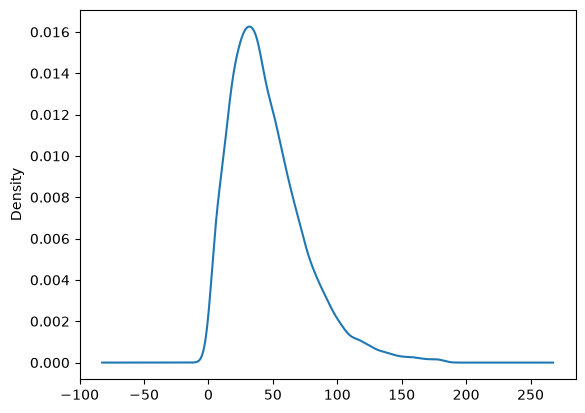

In [83]:
df['training_hours'].plot(kind='kde')

<Axes: ylabel='Frequency'>

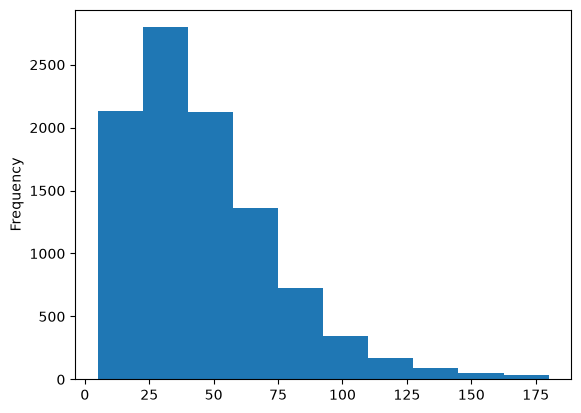

In [84]:
df['training_hours'].plot(kind='hist')

In [103]:
df['training_hours'] = df.groupby('job_level')['training_hours'].transform(
    lambda group: group.fillna(group.median())
)

In [104]:
df['training_hours'].isnull().sum()

np.int64(0)

In [96]:
print("Data Type:", df['projects_completed'].dtype)
print("Missing Count:", df['projects_completed'].isnull().sum())
print("\nSummary Statistics:")
print(df['projects_completed'].describe())
print("\nSkewness:", df['projects_completed'].skew())

Data Type: int64
Missing Count: 0

Summary Statistics:
count    10000.000000
mean        19.654500
std         12.731887
min          0.000000
25%          9.000000
50%         19.000000
75%         30.000000
max         54.000000
Name: projects_completed, dtype: float64

Skewness: 0.24019734030262097


In [97]:
df['projects_completed'].corr(df['annual_salary'])

np.float64(0.6879361530991353)

In [98]:
df['projects_completed'].corr(df['experience_years'])

np.float64(0.9479257199505009)

In [99]:
# 4. Feature Engineering: Productivity Velocity
# Adding +1 prevents division by zero for freshers (experience_years = 0)
df['projects_per_year'] = df['projects_completed'] / (df['experience_years'] + 1)

print(df[['experience_years', 'projects_completed', 'projects_per_year']].head())

   experience_years  projects_completed  projects_per_year
0               0.0                  11          11.000000
1              30.8                  41           1.289308
2              23.0                  30           1.250000
3               7.8                   5           0.568182
4              16.3                  16           0.924855


In [100]:
print("Data Type:", df['performance_score'].dtype)
print("Missing Count:", df['performance_score'].isnull().sum())
print("Missing Percentage: {:.2f}%".format((df['performance_score'].isnull().sum() / len(df)) * 100))
print("\nSummary Statistics:")
print(df['performance_score'].describe())
print("\nSkewness:", df['performance_score'].skew())

Data Type: float64
Missing Count: 120
Missing Percentage: 1.20%

Summary Statistics:
count    9880.000000
mean       81.557298
std        13.855338
min        36.000000
25%        71.000000
50%        81.800000
75%        94.000000
max       100.000000
Name: performance_score, dtype: float64

Skewness: -0.280228861231218


In [101]:
df['performance_score'].corr(df['annual_salary'])

np.float64(0.6247145176199038)

In [102]:
df['performance_score'].corr(df['training_hours'])

np.float64(0.761627324978805)

In [105]:
df['performance_score'] = df.groupby('job_level')['performance_score'].transform(
    lambda group: group.fillna(group.median())
)

In [106]:
df['performance_score'].isnull().sum()

np.int64(0)

In [107]:
print("Data Type:", df['weekly_work_hours'].dtype)
print("Missing Count:", df['weekly_work_hours'].isnull().sum())
print("\nSummary Statistics:")
print(df['weekly_work_hours'].describe())
print("\nSkewness:", df['weekly_work_hours'].skew())

Data Type: float64
Missing Count: 0

Summary Statistics:
count    10000.000000
mean        43.941180
std          7.016267
min         25.000000
25%         39.200000
50%         43.900000
75%         48.700000
max         70.000000
Name: weekly_work_hours, dtype: float64

Skewness: 0.08189948228133162


In [108]:
df['weekly_work_hours'].corr(df['annual_salary'])

np.float64(0.00844564151995157)

In [109]:
print("Data Type:", df['commute_minutes'].dtype)
print("Missing Count:", df['commute_minutes'].isnull().sum())
print("Missing Percentage: {:.2f}%".format((df['commute_minutes'].isnull().sum() / len(df)) * 100))
print("\nSummary Statistics:")
print(df['commute_minutes'].describe())
print("\nSkewness:", df['commute_minutes'].skew())

Data Type: float64
Missing Count: 150
Missing Percentage: 1.50%

Summary Statistics:
count    9850.000000
mean       32.778426
std        21.906525
min         5.000000
25%        16.400000
50%        27.900000
75%        43.900000
max       120.000000
Name: commute_minutes, dtype: float64

Skewness: 1.2249152074208187


In [110]:
df['commute_minutes'].corr(df['annual_salary'])

np.float64(-0.042458532653196726)

In [111]:
df['commute_minutes'].corr(df['job_satisfaction'])

np.float64(-0.3304229725384764)

In [112]:
df['commute_minutes'] = df.groupby('city')['commute_minutes'].transform(
    lambda group: group.fillna(group.median())
)

In [113]:
df['commute_minutes'].isnull().sum()

np.int64(0)

In [114]:
print("Data Type:", df['job_satisfaction'].dtype)
print("Missing Count:", df['job_satisfaction'].isnull().sum())
print("Missing Percentage: {:.2f}%".format((df['job_satisfaction'].isnull().sum() / len(df)) * 100))
print("\nSummary Statistics:")
print(df['job_satisfaction'].describe())
print("\nSkewness:", df['job_satisfaction'].skew())

Data Type: float64
Missing Count: 200
Missing Percentage: 2.00%

Summary Statistics:
count    9800.000000
mean        7.124622
std         1.201488
min         1.000000
25%         6.300000
50%         7.100000
75%         7.900000
max        10.000000
Name: job_satisfaction, dtype: float64

Skewness: -0.12477475980362597


In [115]:
df['job_satisfaction'].corr(df['annual_salary'])

np.float64(0.15881582311908884)

In [116]:
df['job_satisfaction'].corr(df['commute_minutes'])

np.float64(-0.32745033812709545)

In [117]:
df['job_satisfaction'] = df['job_satisfaction'].fillna(df['job_satisfaction'].median())

In [118]:
df['job_satisfaction'].isnull().sum()

np.int64(0)

In [119]:
print("Data Type:", df['bonus_percentage'].dtype)
print("Missing Count:", df['bonus_percentage'].isnull().sum())
print("Missing Percentage: {:.2f}%".format((df['bonus_percentage'].isnull().sum() / len(df)) * 100))
print("\nSummary Statistics:")
print(df['bonus_percentage'].describe())
print("\nSkewness:", df['bonus_percentage'].skew())

Data Type: float64
Missing Count: 100
Missing Percentage: 1.00%

Summary Statistics:
count    9900.000000
mean        7.346723
std         2.617285
min         0.000000
25%         5.590000
50%         7.310000
75%         9.100000
max        17.270000
Name: bonus_percentage, dtype: float64

Skewness: 0.03750016792052335


In [120]:
df['bonus_percentage'].corr(df['annual_salary'])

np.float64(0.4395824609065932)

In [121]:
df['bonus_percentage'].corr(df['performance_score'])

np.float64(0.36626679844918386)

In [122]:
df['bonus_percentage'] = df.groupby(['department', 'job_level'])['bonus_percentage'].transform(
    lambda group: group.fillna(group.median())
)

In [123]:
df['bonus_percentage'].isnull().sum()

np.int64(0)

In [ ]:
print("Data Type:", df['annual_salary'].dtype)
print("Missing Count:", df['annual_salary'].isnull().sum())
print("\nSummary Statistics:")
print(df['annual_salary'].describe().apply(lambda x: f"₹{x:,.2f}"))

Data Type: int64
Missing Count: 0

Summary Statistics:
count       ₹10,000.00
mean     ₹1,338,854.81
std        ₹242,820.58
min        ₹585,900.00
25%      ₹1,162,875.00
50%      ₹1,336,850.00
75%      ₹1,513,400.00
max      ₹2,132,400.00
Name: annual_salary, dtype: str


In [125]:
# 2. Skewness, Kurtosis aur IQR formula
skew_val = df['annual_salary'].skew()
kurt_val = df['annual_salary'].kurtosis()
print(f"Skewness: {skew_val:.4f}")
print(f"Kurtosis: {kurt_val:.4f}")

# IQR (Interquartile Range) formula se outliers dhoondna
Q1 = df['annual_salary'].quantile(0.25)
Q3 = df['annual_salary'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['annual_salary'] < lower_limit) | (df['annual_salary'] > upper_limit)]
print(f"\nLower Limit: ₹{lower_limit:,.2f}")
print(f"Upper Limit: ₹{upper_limit:,.2f}")
print(f"Number of Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Skewness: 0.0571
Kurtosis: -0.3820

Lower Limit: ₹637,087.50
Upper Limit: ₹2,039,187.50
Number of Outliers: 10 (0.10%)


<Axes: >

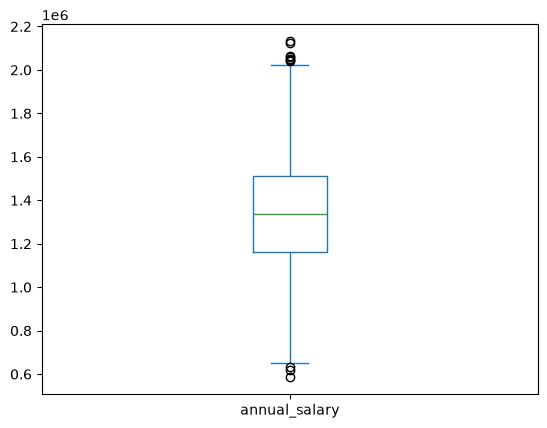

In [127]:
df['annual_salary'].plot(kind='box')

<Axes: ylabel='Density'>

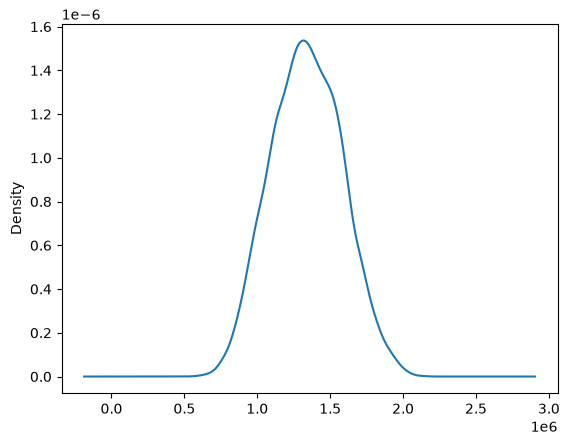

In [128]:
df['annual_salary'].plot(kind='kde')

<Axes: ylabel='Frequency'>

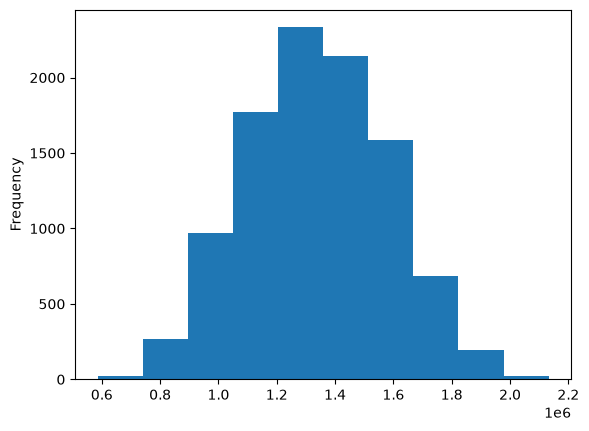

In [129]:
df['annual_salary'].plot(kind='hist')

In [130]:
cols_to_drop = ['education_years', 'weekly_work_hours', 'commute_minutes']
df_selected = df.drop(columns=cols_to_drop)

In [132]:
print("Remaining Columns Count:", df_selected.shape[1])
print("Selected Columns:", df_selected.columns.tolist())

Remaining Columns Count: 15
Selected Columns: ['age', 'experience_years', 'education', 'city', 'department', 'job_level', 'remote_work', 'company_size', 'training_hours', 'projects_completed', 'performance_score', 'job_satisfaction', 'bonus_percentage', 'annual_salary', 'projects_per_year']


In [134]:
df_selected.shape

(10000, 15)

In [135]:
from sklearn.preprocessing import OrdinalEncoder

# 1. Custom rank order list define karo
categories_order = [
    ['High School', 'Bachelor', 'Master', 'PhD'],          # education ke liye
    ['Junior', 'Mid', 'Senior', 'Manager'],                # job_level ke liye
    ['Small', 'Medium', 'Large', 'Enterprise']             # company_size ke liye
]

# 2. Encoder initialize karo custom categories ke sath
encoder = OrdinalEncoder(categories=categories_order)

# 3. Fit aur transform karo
cols_to_encode = ['education', 'job_level', 'company_size']
df_selected[cols_to_encode] = encoder.fit_transform(df_selected[cols_to_encode])

In [136]:
from sklearn.preprocessing import OneHotEncoder

# 1. Nominal columns ki list specify karo
nominal_cols = ['city', 'department', 'remote_work']

# 2. OneHotEncoder initialize karo
# drop='first' dummy variable trap se bachata hai
# sparse_output=False se direct numpy array milta hai
ohe = OneHotEncoder(drop='first', sparse_output=False)

# 3. Fit aur transform karo
ohe_array = ohe.fit_transform(df_selected[nominal_cols])

# 4. Encoded array ko wapas DataFrame me convert karo readable column names ke sath
ohe_feature_names = ohe.get_feature_names_out(nominal_cols)
df_ohe = pd.DataFrame(ohe_array, columns=ohe_feature_names, index=df_selected.index)

print("Generated dummy columns count:", len(ohe_feature_names))
print("\nSample dummy column names:")
print(list(ohe_feature_names)[:6])

Generated dummy columns count: 13

Sample dummy column names:
['city_Bangalore', 'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Kolkata', 'city_Mumbai']


In [137]:
# 1. Purane nominal text columns ko drop karo
df_rest = df_selected.drop(columns=nominal_cols)

# 2. Numerical/Ordinal columns aur OHE columns ko horizontally concatenate (jod) do
df_final = pd.concat([df_rest, df_ohe], axis=1)

print("Final dataset shape (Rows, Columns):", df_final.shape)
print("\nFirst 2 rows of encoded dataset:")
print(df_final.head(2))

Final dataset shape (Rows, Columns): (10000, 25)

First 2 rows of encoded dataset:
   age  experience_years  education  job_level  company_size  training_hours  \
0   24               0.0        1.0        2.0           1.0            49.2   
1   51              30.8        0.0        2.0           0.0             5.0   

   projects_completed  performance_score  job_satisfaction  bonus_percentage  \
0                  11               79.9               5.5              9.64   
1                  41               55.4               7.7              9.60   

   ...  city_Hyderabad  city_Kolkata  city_Mumbai  city_Pune  department_HR  \
0  ...             0.0           0.0          0.0        0.0            1.0   
1  ...             0.0           0.0          0.0        0.0            0.0   

   department_IT  department_Marketing  department_Operations  \
0            0.0                   0.0                    0.0   
1            0.0                   0.0                    1.0   

 

In [138]:
from sklearn.model_selection import train_test_split

# 1. Target variable (annual_salary) ko alag karo aur features alag karo
X = df_final.drop(columns=['annual_salary'])
y = df_final['annual_salary']

# 2. Train-Test Split (80% training ke liye, 20% testing ke liye)
# random_state=42 se har baar same data divide hoga (reproducibility ke liye)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Shape check karo
print("Features (X_train) Shape:", X_train.shape)
print("Features (X_test) Shape :", X_test.shape)
print("Target (y_train) Shape   :", y_train.shape)
print("Target (y_test) Shape    :", y_test.shape)

Features (X_train) Shape: (8000, 24)
Features (X_test) Shape : (2000, 24)
Target (y_train) Shape   : (8000,)
Target (y_test) Shape    : (2000,)


In [139]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](24,)","[ 3456.79, 4951.69,43651.33,...,-6336.68,-9935.6 ,18843.17]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](24,)","['age','experience_years','education',...,'department_Operations', 'department_Sales','remote_work_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.233e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,24
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(24)


In [140]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Test data par salary predict karein
y_pred = model.predict(X_test)

# 2. Evaluation metrics calculate karein
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 3. Print metrics
print(f"R² Score (Accuracy/Variance Explained): {r2:.4f}")
print(f"Mean Absolute Error (MAE)            : ₹{mae:,.2f}")
print(f"Root Mean Squared Error (RMSE)       : ₹{rmse:,.2f}")

# 4. Error percentage compare karein
error_percentage = (mae / y_test.mean()) * 100
print(f"Average Error Percentage             : {error_percentage:.2f}%")

R² Score (Accuracy/Variance Explained): 0.9015
Mean Absolute Error (MAE)            : ₹61,202.08
Root Mean Squared Error (RMSE)       : ₹76,733.50
Average Error Percentage             : 4.56%


In [141]:
new_employee = pd.DataFrame([{
    'age': 32,
    'experience_years': 8.0,
    'education': 3,          # 1: High School, 2: Bachelor, 3: Master, 4: PhD
    'job_level': 3,          # 1: Junior, 2: Mid, 3: Senior, 4: Manager
    'company_size': 3,       # 1: Small, 2: Medium, 3: Large, 4: Enterprise
    'training_hours': 45.0,
    'projects_completed': 18,
    'performance_score': 88.0,
    'job_satisfaction': 8.0,
    'bonus_percentage': 9.5,
    'city': 'Bangalore',
    'department': 'IT',
    'remote_work': 'Yes'
}])
new_employee['projects_per_year'] = new_employee['projects_completed'] / (new_employee['experience_years'] + 1)

# 3. Categorical nominal columns ko pehle se trained 'ohe' se transform karo
nominal_cols = ['city', 'department', 'remote_work']
new_ohe_array = ohe.transform(new_employee[nominal_cols])
new_df_ohe = pd.DataFrame(new_ohe_array, columns=ohe_feature_names)

# 4. Concatenate karke format match karo
new_employee_rest = new_employee.drop(columns=nominal_cols)
new_input_ready = pd.concat([new_employee_rest, new_df_ohe], axis=1)

# Column sequence training features jaisa same arrange karna zaroori hai
new_input_ready = new_input_ready[X_train.columns]

# 5. Salary predict karo
predicted_salary = model.predict(new_input_ready)[0]

print(f"--- Prediction Result ---")
print(f"Predicted Annual Salary: ₹{predicted_salary:,.2f}")

--- Prediction Result ---
Predicted Annual Salary: ₹1,630,873.23
